**NJN Full Evaluation Pack — EffNet Full Hybrid vs PCA-Hybrid (V1)**

* Will train EfficientNet Full Hybrid (Best)
* Will train EfficientNet PCA-Hybrid (dim=128)
* Will evaluate two models in the same test split
* Will show for both: ROC, PR, Calibration, Probability hist, Bootstrap AUC 95% CI + AUC bootstrap hist
* Will print summary table at the end

In [1]:
!pip -q install opencv-python numpy pandas matplotlib seaborn scikit-learn scipy tqdm tensorflow joblib

import os, glob, random
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis

from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score,
    classification_report, confusion_matrix,
    brier_score_loss
)
from sklearn.calibration import calibration_curve

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Seed + Dataset path + Load + Label**

In [3]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

sayem = "/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN"

img_exts = ("*.jpg","*.jpeg","*.png","*.bmp","*.webp")
all_imgs = []
for ext in img_exts:
    all_imgs += glob.glob(os.path.join(sayem, "**", ext), recursive=True)

def infer_label_from_path(p):
    lp = p.lower()
    pos_keys = ["jaundice","icteric","positive","pos","case","patient","affected","yellow"]
    neg_keys = ["normal","control","negative","neg","healthy","non"]
    if any(k in lp for k in pos_keys): return 1
    if any(k in lp for k in neg_keys): return 0
    return None

pairs = [(p, infer_label_from_path(p)) for p in all_imgs]
pairs = [(p,l) for p,l in pairs if l is not None]

print("Total labeled:", len(pairs))
print("Class counts (0,1):", np.bincount([l for _,l in pairs]))

Total labeled: 760
Class counts (0,1): [560 200]


**ROI functions (FH/CH/AB)**

In [4]:
def extract_forehead_roi(img_bgr):
    h, w = img_bgr.shape[:2]
    x1 = int(0.25*w); x2 = int(0.75*w)
    y1 = int(0.10*h); y2 = int(0.40*h)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None

def extract_chest_roi(img_bgr):
    h, w = img_bgr.shape[:2]
    x1 = int(0.25*w); x2 = int(0.75*w)
    y1 = int(0.40*h); y2 = int(0.80*h)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None

def extract_abdomen_roi(img_bgr):
    h, w = img_bgr.shape[:2]
    x1 = int(0.25*w); x2 = int(0.75*w)
    y1 = int(0.60*h); y2 = int(0.92*h)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None

**Preprocess + skin mask + classical features**

In [5]:
def gray_world_white_balance(img_bgr):
    img = img_bgr.astype(np.float32)
    b, g, r = cv2.split(img)
    mb, mg, mr = np.mean(b), np.mean(g), np.mean(r)
    m = (mb + mg + mr) / 3.0
    b = b * (m / (mb + 1e-6))
    g = g * (m / (mg + 1e-6))
    r = r * (m / (mr + 1e-6))
    out = cv2.merge([b,g,r])
    return np.clip(out, 0, 255).astype(np.uint8)

def normalize_clahe_lab(roi_bgr, clip=2.5):
    lab = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2LAB)
    L, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(8,8))
    L2 = clahe.apply(L)
    lab2 = cv2.merge([L2, a, b])
    return cv2.cvtColor(lab2, cv2.COLOR_LAB2BGR)

def preprocess_roi(roi_bgr):
    roi_bgr = gray_world_white_balance(roi_bgr)
    roi_bgr = normalize_clahe_lab(roi_bgr, clip=2.5)
    return roi_bgr

def skin_mask_hsv(roi_bgr):
    hsv = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2HSV)
    lower = np.array([0, 20, 40], dtype=np.uint8)
    upper = np.array([25, 255, 255], dtype=np.uint8)
    mask = cv2.inRange(hsv, lower, upper)
    k = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=1)
    return mask

def masked_stats(channel, mask):
    vals = channel[mask==255].astype(np.float32)
    if vals.size < 30:
        return (np.nan,)*6
    return (
        float(np.mean(vals)),
        float(np.std(vals)),
        float(np.median(vals)),
        float(skew(vals)),
        float(kurtosis(vals)),
        float(np.percentile(vals, 90))
    )

def extract_classical_features(roi_bgr):
    roi_bgr = preprocess_roi(roi_bgr)
    mask = skin_mask_hsv(roi_bgr)
    if np.sum(mask==255) < 200:
        mask = np.ones(roi_bgr.shape[:2], dtype=np.uint8)*255

    roi_rgb = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)
    R = roi_rgb[:,:,0]; G = roi_rgb[:,:,1]; B = roi_rgb[:,:,2]

    Rm, Rs, _, _, _, R90 = masked_stats(R, mask)
    Gm, Gs, _, _, _, G90 = masked_stats(G, mask)
    Bm, Bs, _, _, _, B90 = masked_stats(B, mask)

    ygi = float((Rm + Gm) / (Bm + 1e-6))
    r_over_b = float(Rm / (Bm + 1e-6))
    g_over_b = float(Gm / (Bm + 1e-6))

    denom = (Rm + Gm + Bm + 1e-6)
    r_ch = float(Rm / denom); g_ch = float(Gm / denom); b_ch = float(Bm / denom)

    hsv = cv2.cvtColor(roi_rgb.astype(np.uint8), cv2.COLOR_RGB2HSV).astype(np.float32)
    H = hsv[:,:,0]; S = hsv[:,:,1]; V = hsv[:,:,2]
    Hm, _, _, _, _, _ = masked_stats(H, mask)
    Sm, _, _, _, _, _ = masked_stats(S, mask)
    Vm, Vs, _, _, _, _ = masked_stats(V, mask)

    Hvals = H[mask==255]
    hue_peak = float(np.argmax(np.histogram(Hvals, bins=18, range=(0,180))[0])) if Hvals.size > 30 else np.nan

    lab = cv2.cvtColor(roi_rgb.astype(np.uint8), cv2.COLOR_RGB2LAB).astype(np.float32)
    L = lab[:,:,0]; a = lab[:,:,1]; b = lab[:,:,2]
    Lm, _, _, _, _, _ = masked_stats(L, mask)
    am, _, _, _, _, _ = masked_stats(a, mask)
    bm, _, _, _, _, b90 = masked_stats(b, mask)

    bvals = b[mask==255]
    yellow_prop = float(np.mean(bvals > np.percentile(bvals, 75))) if bvals.size > 30 else np.nan

    feats = {
        "R_mean": Rm, "G_mean": Gm, "B_mean": Bm,
        "R_std": Rs, "G_std": Gs, "B_std": Bs,
        "R_p90": R90, "G_p90": G90, "B_p90": B90,
        "YGI": ygi,
        "R_over_B": r_over_b,
        "G_over_B": g_over_b,
        "r_ch": r_ch, "g_ch": g_ch, "b_ch": b_ch,
        "H_mean": Hm, "S_mean": Sm, "V_mean": Vm,
        "V_std": Vs,
        "Hue_peak_bin": hue_peak,
        "L_mean": Lm, "a_mean": am, "Lab_b_mean": bm,
        "Lab_b_p90": b90,
        "yellow_prop": yellow_prop
    }
    feats["YGI_x_b"] = feats["YGI"] * feats["Lab_b_mean"]
    return feats

**EfficientNet embedding extractor**

In [6]:
IMG_SIZE = 224

eff = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
eff.trainable = False

def roi_to_tensor(roi_bgr):
    roi = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB)
    roi = cv2.resize(roi, (IMG_SIZE, IMG_SIZE))
    x = roi.astype(np.float32)
    x = preprocess_input(x)
    return x

def get_eff_embedding(img_bgr, roi_fn):
    roi = roi_fn(img_bgr)
    if roi is None:
        return None
    x = roi_to_tensor(roi)
    emb = eff(np.expand_dims(x, 0), training=False).numpy().ravel()
    return emb

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Build dataset (classical + deep mats aligned)**

In [7]:
rows = []
FH_list, CH_list, AB_list = [], [], []
failed = 0

for p, label in tqdm(pairs, desc="Building EffNet fullpack dataset"):
    img = cv2.imread(p)
    if img is None:
        failed += 1
        continue

    fh = extract_forehead_roi(img)
    ch = extract_chest_roi(img)
    ab = extract_abdomen_roi(img)
    if fh is None or ch is None or ab is None:
        failed += 1
        continue

    fh_feat = extract_classical_features(fh)
    ch_feat = extract_classical_features(ch)
    ab_feat = extract_classical_features(ab)

    e_fh = get_eff_embedding(img, extract_forehead_roi)
    e_ch = get_eff_embedding(img, extract_chest_roi)
    e_ab = get_eff_embedding(img, extract_abdomen_roi)

    if (e_fh is None) or (e_ch is None) or (e_ab is None):
        failed += 1
        continue

    row = {"path": p, "label": int(label)}
    row.update({f"FH_{k}": v for k,v in fh_feat.items()})
    row.update({f"CH_{k}": v for k,v in ch_feat.items()})
    row.update({f"AB_{k}": v for k,v in ab_feat.items()})
    rows.append(row)

    FH_list.append(e_fh); CH_list.append(e_ch); AB_list.append(e_ab)

X_classical_df = pd.DataFrame(rows)
FH_mat = np.vstack(FH_list)
CH_mat = np.vstack(CH_list)
AB_mat = np.vstack(AB_list)

print("Classical DF:", X_classical_df.shape, "Failed:", failed)
print("Embeddings:", FH_mat.shape, CH_mat.shape, AB_mat.shape)

Building EffNet fullpack dataset: 100%|██████████| 760/760 [25:35<00:00,  2.02s/it]

Classical DF: (760, 80) Failed: 0
Embeddings: (760, 1280) (760, 1280) (760, 1280)


**Build Full Hybrid & PCA-Hybrid matrices + SAME test split**

In [8]:
# classical
Xc = X_classical_df.drop(columns=["path","label"])
imputer = SimpleImputer(strategy="median")
Xc = imputer.fit_transform(Xc)

# deep
deep_all = np.hstack([FH_mat, CH_mat, AB_mat])  # (N,3840)
y = X_classical_df["label"].astype(int).values

# Full Hybrid
X_full = np.hstack([Xc, deep_all])

# PCA-Hybrid (dim=128)
pca_dim = 128
pca = PCA(n_components=pca_dim, random_state=42)
deep_pca = pca.fit_transform(deep_all)
X_pca = np.hstack([Xc, deep_pca])

# SAME split indices for both models
idx_all = np.arange(len(y))
train_idx, test_idx = train_test_split(idx_all, test_size=0.2, random_state=42, stratify=y)

X_full_train, X_full_test = X_full[train_idx], X_full[test_idx]
X_pca_train,  X_pca_test  = X_pca[train_idx],  X_pca[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("Train/Test:", len(train_idx), len(test_idx))
print("Test dist:", np.bincount(y_test))

Train/Test: 608 152
Test dist: [112  40]


**Train models + get probabilities (Full & PCA)**

In [9]:
svm_full = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced"))
])
svm_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced"))
])

svm_full.fit(X_full_train, y_train)
svm_pca.fit(X_pca_train, y_train)

prob_full = svm_full.predict_proba(X_full_test)[:,1]
prob_pca  = svm_pca.predict_proba(X_pca_test)[:,1]

print("Full Hybrid Test AUC:", roc_auc_score(y_test, prob_full))
print("PCA-Hybrid Test AUC :", roc_auc_score(y_test, prob_pca))

Full Hybrid Test AUC: 0.9227678571428571
PCA-Hybrid Test AUC : 0.9178571428571428


**Full Evaluation Pack function (ROC+PR+Calib+Hist+Bootstrap CI)**

In [11]:
def full_eval_pack(y_true, prob, title="Model", n_boot=2000, seed=42):
    # ROC
    fpr, tpr, _ = roc_curve(y_true, prob)
    rocA = auc(fpr, tpr)

    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, linewidth=2, label=f"AUC={rocA:.3f}")
    plt.plot([0,1],[0,1],'--', color='gray')
    plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.title(f"ROC — {title}")
    plt.legend(); plt.grid(alpha=0.3)
    plt.show()

    # PR
    prec, rec, _ = precision_recall_curve(y_true, prob)
    ap = average_precision_score(y_true, prob)

    plt.figure(figsize=(6,4))
    plt.plot(rec, prec, linewidth=2)
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title(f"PR — {title} (AP={ap:.3f})")
    plt.grid(alpha=0.3)
    plt.show()

    # Calibration + Brier
    brier = brier_score_loss(y_true, prob)
    frac_pos, mean_pred = calibration_curve(y_true, prob, n_bins=10)

    plt.figure(figsize=(6,4))
    plt.plot(mean_pred, frac_pos, "o-", label="Model")
    plt.plot([0,1],[0,1], "--", label="Perfect")
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.title(f"Calibration — {title} (Brier={brier:.3f})")
    plt.legend(); plt.grid(alpha=0.3)
    plt.show()

    # Prob hist
    plt.figure(figsize=(6,4))
    plt.hist(prob[y_true==0], bins=15, alpha=0.6, label="Normal(0)")
    plt.hist(prob[y_true==1], bins=15, alpha=0.6, label="Jaundice(1)")
    plt.title(f"Probability Distribution — {title}")
    plt.xlabel("Predicted probability"); plt.ylabel("Frequency")
    plt.legend(); plt.tight_layout()
    plt.show()

    # Bootstrap AUC CI
    rng = np.random.RandomState(seed)
    boot = []
    for _ in tqdm(range(n_boot), desc=f"Bootstrap AUC — {title}"):
        idx = rng.randint(0, len(prob), len(prob))
        if len(np.unique(y_true[idx])) < 2:
            continue
        boot.append(roc_auc_score(y_true[idx], prob[idx]))

    boot = np.array(boot)
    low, high = np.percentile(boot, 2.5), np.percentile(boot, 97.5)

    print(f"\n===== {title} Summary =====")
    print("AUC:", float(roc_auc_score(y_true, prob)))
    print("95% CI:", [float(low), float(high)])
    print("Brier:", float(brier))
    print("AP:", float(ap))

    plt.figure(figsize=(6,4))
    plt.hist(boot, bins=30, alpha=0.75)
    plt.axvline(low, linestyle="--", label="2.5%")
    plt.axvline(high, linestyle="--", label="97.5%")
    plt.axvline(np.mean(boot), label="Mean")
    plt.title(f"Bootstrap AUC Distribution — {title}")
    plt.xlabel("AUC"); plt.ylabel("Count")
    plt.legend(); plt.show()

    return {"AUC": rocA, "CI_low": low, "CI_high": high, "Brier": brier, "AP": ap}

**Run Full Pack for BOTH models**

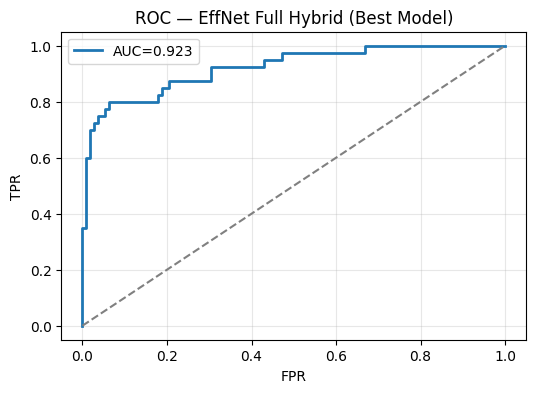

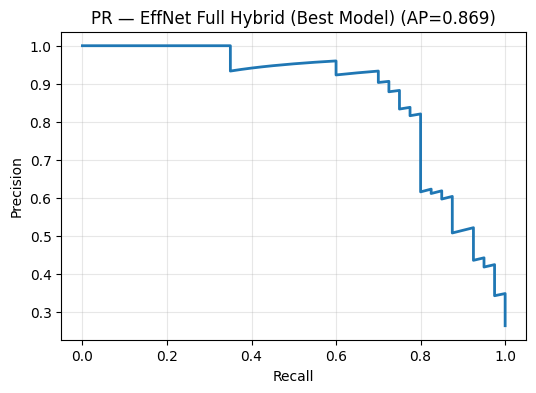

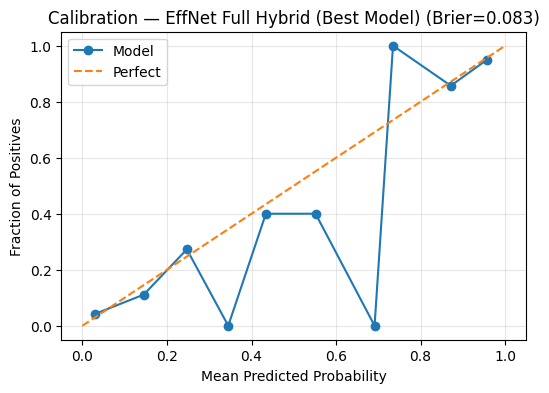

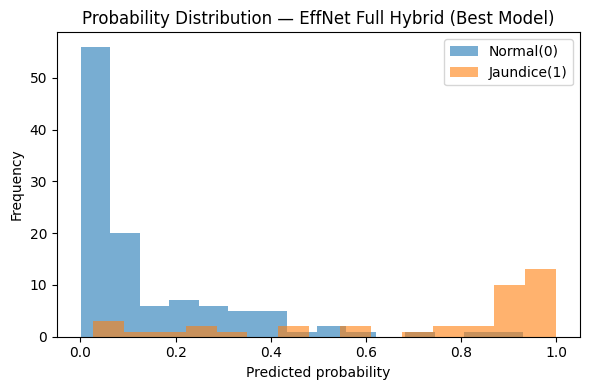

Bootstrap AUC — EffNet Full Hybrid (Best Model): 100%|██████████| 2000/2000 [00:09<00:00, 201.50it/s]



===== EffNet Full Hybrid (Best Model) Summary =====
AUC: 0.9227678571428571
95% CI: [0.8688181263095783, 0.9677009106267402]
Brier: 0.08344302165976582
AP: 0.8690343314867482


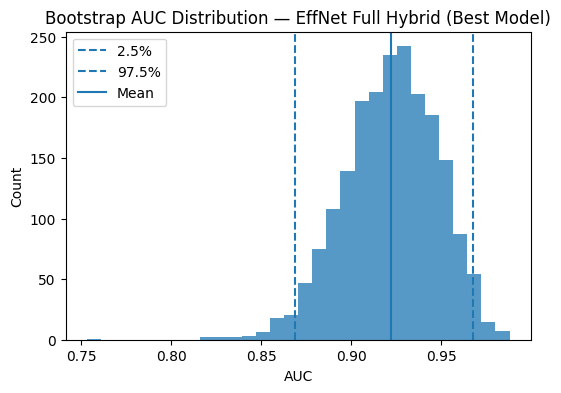

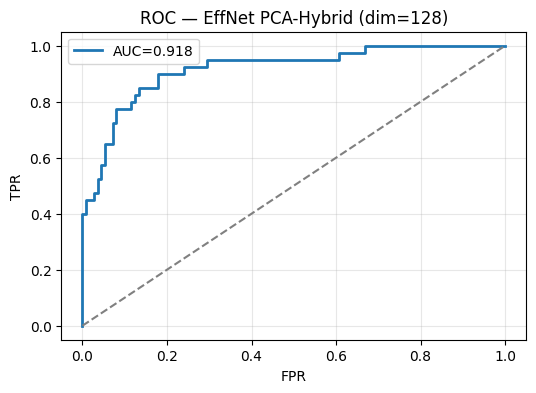

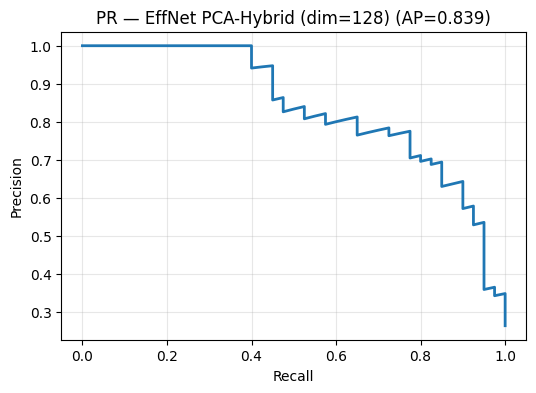

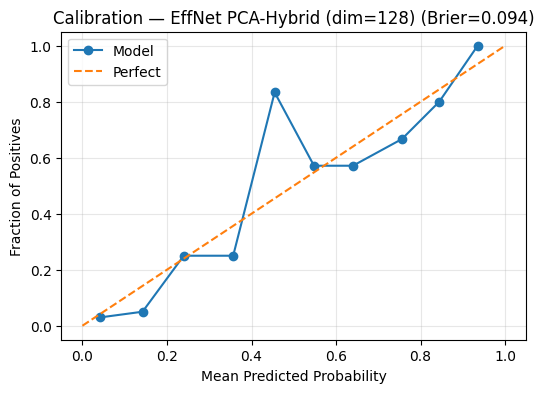

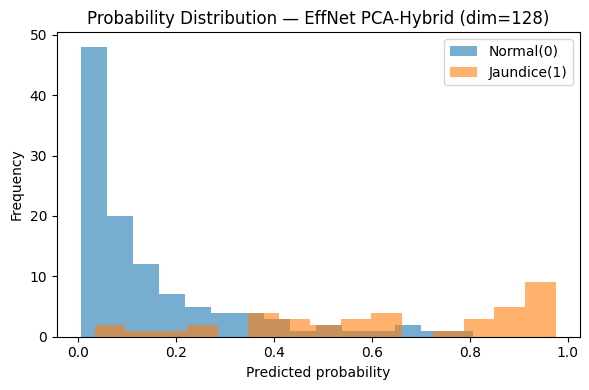

Bootstrap AUC — EffNet PCA-Hybrid (dim=128): 100%|██████████| 2000/2000 [00:04<00:00, 455.87it/s]



===== EffNet PCA-Hybrid (dim=128) Summary =====
AUC: 0.9178571428571428
95% CI: [0.8632355699966568, 0.9634981652430331]
Brier: 0.09398406137600261
AP: 0.8393295975157905


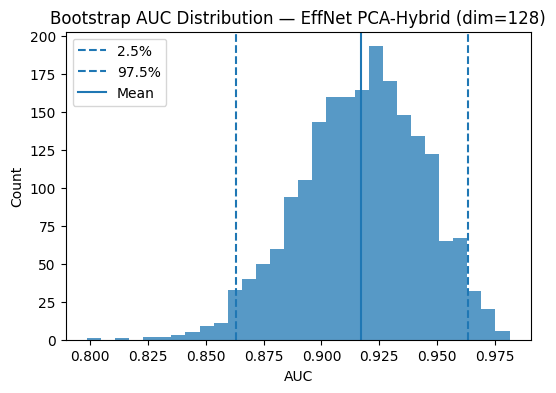


=== Quick Comparison Summary ===
Full Hybrid: {'AUC': np.float64(0.9227678571428571), 'CI_low': np.float64(0.8688181263095783), 'CI_high': np.float64(0.9677009106267402), 'Brier': np.float64(0.08344302165976582), 'AP': np.float64(0.8690343314867482)}
PCA Hybrid : {'AUC': np.float64(0.9178571428571428), 'CI_low': np.float64(0.8632355699966568), 'CI_high': np.float64(0.9634981652430331), 'Brier': np.float64(0.09398406137600261), 'AP': np.float64(0.8393295975157905)}


In [12]:
res_full = full_eval_pack(y_test, prob_full, title="EffNet Full Hybrid (Best Model)", n_boot=2000, seed=42)
res_pca  = full_eval_pack(y_test, prob_pca,  title="EffNet PCA-Hybrid (dim=128)", n_boot=2000, seed=42)

print("\n=== Quick Comparison Summary ===")
print("Full Hybrid:", res_full)
print("PCA Hybrid :", res_pca)

**Side-by-Side Annotated Panel (Full vs PCA)**

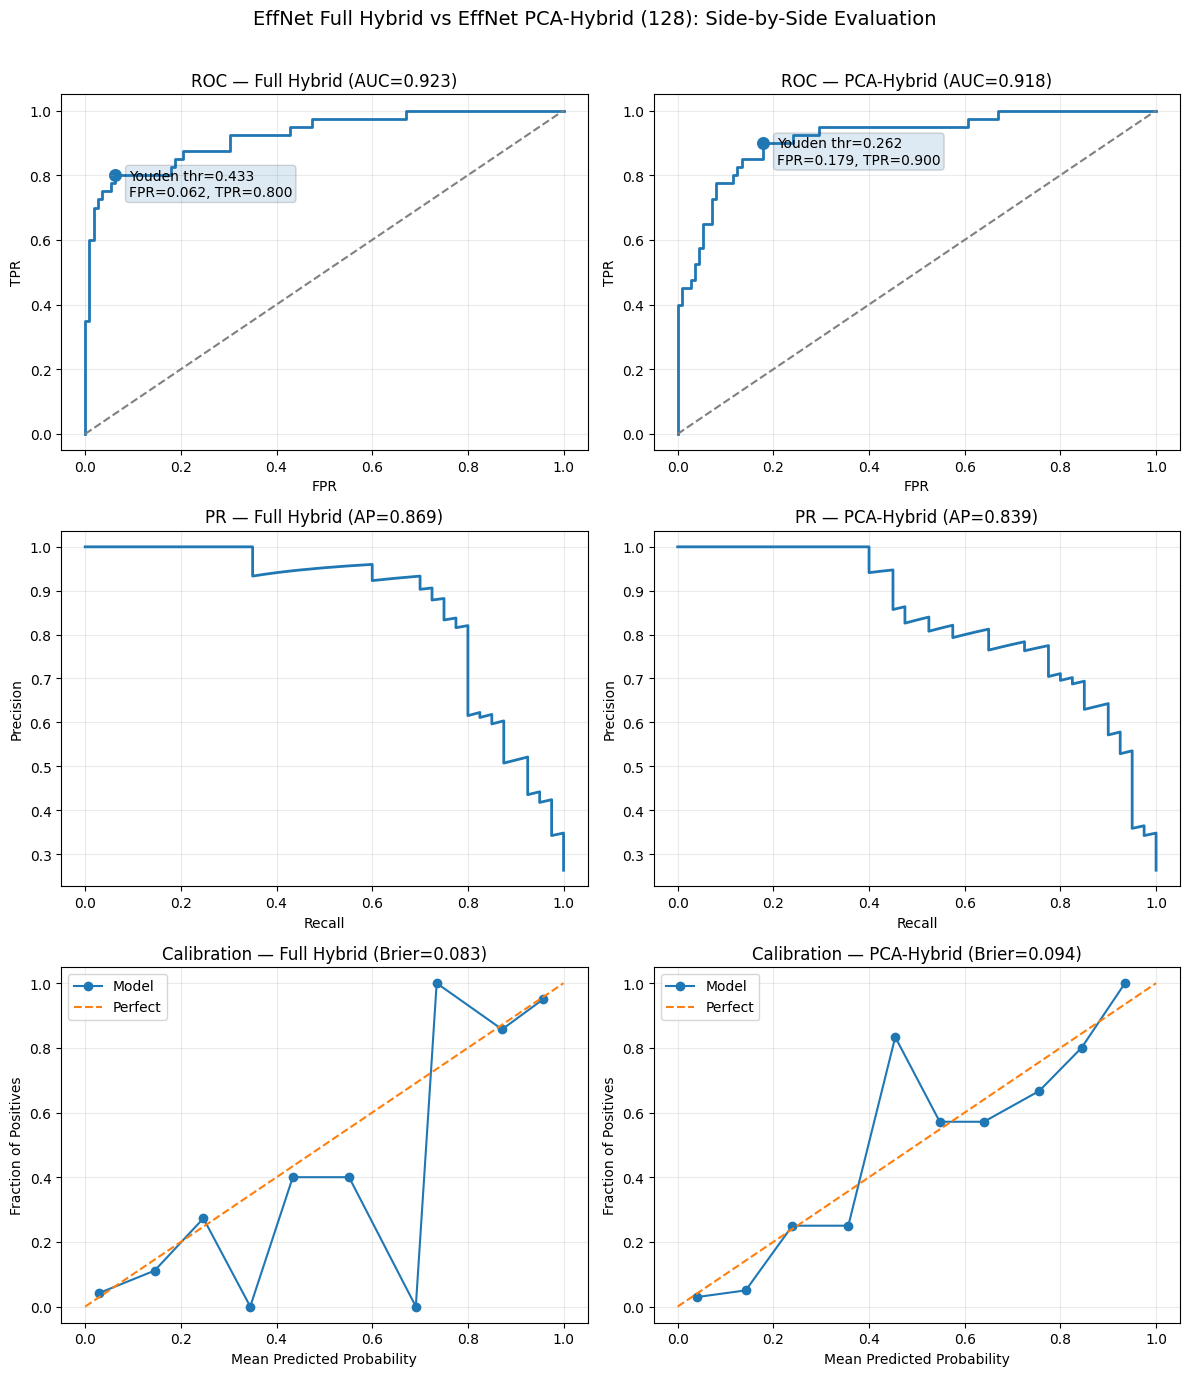

Saved: EffNet_Full_vs_PCAHybrid_Panel.png


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

# ---- Inputs ----
y = y_test
p_full = prob_full
p_pca  = prob_pca

def youden_point(y_true, prob):
    fpr, tpr, thr = roc_curve(y_true, prob)
    j = tpr - fpr
    i = np.argmax(j)
    return fpr, tpr, thr, i

# ---- Metrics ----
# Full
fprF, tprF, thrF, iF = youden_point(y, p_full)
aucF = auc(fprF, tprF)
precF, recF, _ = precision_recall_curve(y, p_full)
apF = average_precision_score(y, p_full)
brierF = brier_score_loss(y, p_full)
fracF, meanF = calibration_curve(y, p_full, n_bins=10)

# PCA
fprP, tprP, thrP, iP = youden_point(y, p_pca)
aucP = auc(fprP, tprP)
precP, recP, _ = precision_recall_curve(y, p_pca)
apP = average_precision_score(y, p_pca)
brierP = brier_score_loss(y, p_pca)
fracP, meanP = calibration_curve(y, p_pca, n_bins=10)

# ---- Plot: 2 columns × 3 rows ----
fig, ax = plt.subplots(3, 2, figsize=(12, 14))
fig.suptitle("EffNet Full Hybrid vs EffNet PCA-Hybrid (128): Side-by-Side Evaluation", fontsize=14)

# ========== Row 1: ROC ==========
# Full ROC
ax[0,0].plot(fprF, tprF, linewidth=2)
ax[0,0].plot([0,1],[0,1],'--', color='gray')
ax[0,0].scatter([fprF[iF]], [tprF[iF]], s=70)
ax[0,0].annotate(
    f"Youden thr={thrF[iF]:.3f}\nFPR={fprF[iF]:.3f}, TPR={tprF[iF]:.3f}",
    (fprF[iF], tprF[iF]),
    textcoords="offset points", xytext=(10, -15),
    bbox=dict(boxstyle="round,pad=0.25", alpha=0.15)
)
ax[0,0].set_title(f"ROC — Full Hybrid (AUC={aucF:.3f})")
ax[0,0].set_xlabel("FPR"); ax[0,0].set_ylabel("TPR")
ax[0,0].grid(alpha=0.25)

# PCA ROC
ax[0,1].plot(fprP, tprP, linewidth=2)
ax[0,1].plot([0,1],[0,1],'--', color='gray')
ax[0,1].scatter([fprP[iP]], [tprP[iP]], s=70)
ax[0,1].annotate(
    f"Youden thr={thrP[iP]:.3f}\nFPR={fprP[iP]:.3f}, TPR={tprP[iP]:.3f}",
    (fprP[iP], tprP[iP]),
    textcoords="offset points", xytext=(10, -15),
    bbox=dict(boxstyle="round,pad=0.25", alpha=0.15)
)
ax[0,1].set_title(f"ROC — PCA-Hybrid (AUC={aucP:.3f})")
ax[0,1].set_xlabel("FPR"); ax[0,1].set_ylabel("TPR")
ax[0,1].grid(alpha=0.25)

# ========== Row 2: PR ==========
ax[1,0].plot(recF, precF, linewidth=2)
ax[1,0].set_title(f"PR — Full Hybrid (AP={apF:.3f})")
ax[1,0].set_xlabel("Recall"); ax[1,0].set_ylabel("Precision")
ax[1,0].grid(alpha=0.25)

ax[1,1].plot(recP, precP, linewidth=2)
ax[1,1].set_title(f"PR — PCA-Hybrid (AP={apP:.3f})")
ax[1,1].set_xlabel("Recall"); ax[1,1].set_ylabel("Precision")
ax[1,1].grid(alpha=0.25)

# ========== Row 3: Calibration ==========
ax[2,0].plot(meanF, fracF, "o-", label="Model")
ax[2,0].plot([0,1],[0,1],"--", label="Perfect")
ax[2,0].set_title(f"Calibration — Full Hybrid (Brier={brierF:.3f})")
ax[2,0].set_xlabel("Mean Predicted Probability")
ax[2,0].set_ylabel("Fraction of Positives")
ax[2,0].legend()
ax[2,0].grid(alpha=0.25)

ax[2,1].plot(meanP, fracP, "o-", label="Model")
ax[2,1].plot([0,1],[0,1],"--", label="Perfect")
ax[2,1].set_title(f"Calibration — PCA-Hybrid (Brier={brierP:.3f})")
ax[2,1].set_xlabel("Mean Predicted Probability")
ax[2,1].set_ylabel("Fraction of Positives")
ax[2,1].legend()
ax[2,1].grid(alpha=0.25)

plt.tight_layout(rect=[0, 0, 1, 0.97])

# ---- Save + Download ----
out_name = "EffNet_Full_vs_PCAHybrid_Panel.png"
plt.savefig(out_name, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_name)

In [15]:
from google.colab import files
files.download("EffNet_Full_vs_PCAHybrid_Panel.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Histogram Panel (with Bootstrap CI)**

Bootstrap: 100%|██████████| 2000/2000 [00:03<00:00, 639.94it/s]


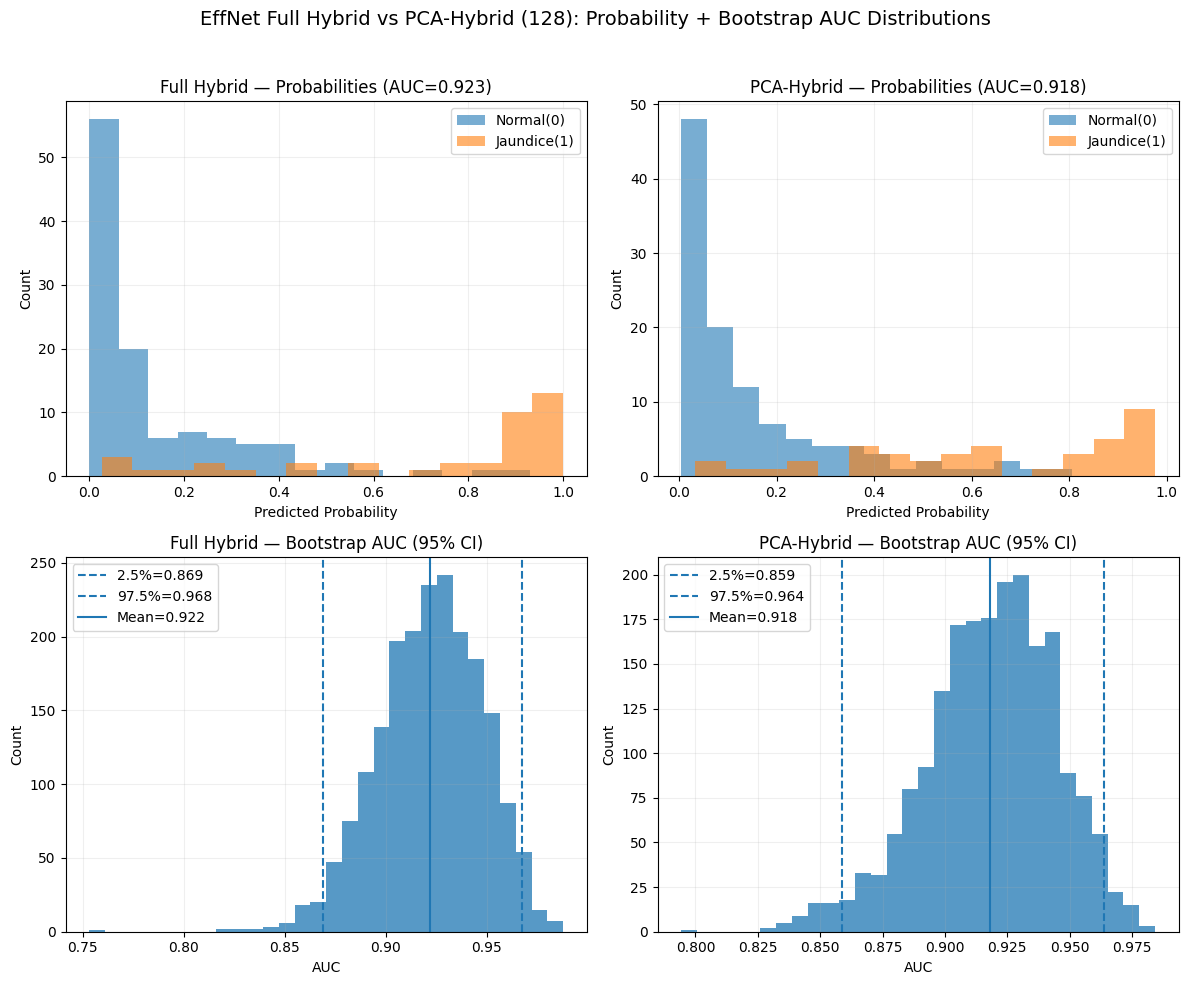

Saved: EffNet_Full_vs_PCAHybrid_HistPanel.png
Full AUC: 0.9227678571428571 CI: (0.8688181263095783, 0.9677009106267402)
PCA  AUC: 0.9178571428571428 CI: (0.8586661607337205, 0.9638397626678876)


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

# Inputs
y = y_test
p_full = prob_full
p_pca  = prob_pca

# Bootstrap helper
def bootstrap_auc(y_true, y_prob, n_boot=2000, seed=42):
    rng = np.random.RandomState(seed)
    vals = []
    n = len(y_prob)
    for _ in tqdm(range(n_boot), desc="Bootstrap"):
        idx = rng.randint(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        vals.append(roc_auc_score(y_true[idx], y_prob[idx]))
    vals = np.array(vals)
    low, high = np.percentile(vals, 2.5), np.percentile(vals, 97.5)
    return vals, float(low), float(high), float(np.mean(vals))

# Compute bootstraps (Full + PCA)
boot_full, lowF, highF, meanF = bootstrap_auc(y, p_full, n_boot=2000, seed=42)
boot_pca,  lowP, highP, meanP = bootstrap_auc(y, p_pca,  n_boot=2000, seed=43)

auc_full = roc_auc_score(y, p_full)
auc_pca  = roc_auc_score(y, p_pca)

# ---- Plot 2×2 panel ----
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("EffNet Full Hybrid vs PCA-Hybrid (128): Probability + Bootstrap AUC Distributions", fontsize=14)

# (1) Full prob hist
ax[0,0].hist(p_full[y==0], bins=15, alpha=0.6, label="Normal(0)")
ax[0,0].hist(p_full[y==1], bins=15, alpha=0.6, label="Jaundice(1)")
ax[0,0].set_title(f"Full Hybrid — Probabilities (AUC={auc_full:.3f})")
ax[0,0].set_xlabel("Predicted Probability"); ax[0,0].set_ylabel("Count")
ax[0,0].legend()
ax[0,0].grid(alpha=0.2)

# (2) PCA prob hist
ax[0,1].hist(p_pca[y==0], bins=15, alpha=0.6, label="Normal(0)")
ax[0,1].hist(p_pca[y==1], bins=15, alpha=0.6, label="Jaundice(1)")
ax[0,1].set_title(f"PCA-Hybrid — Probabilities (AUC={auc_pca:.3f})")
ax[0,1].set_xlabel("Predicted Probability"); ax[0,1].set_ylabel("Count")
ax[0,1].legend()
ax[0,1].grid(alpha=0.2)

# (3) Full bootstrap AUC hist
ax[1,0].hist(boot_full, bins=30, alpha=0.75)
ax[1,0].axvline(lowF, linestyle="--", label=f"2.5%={lowF:.3f}")
ax[1,0].axvline(highF, linestyle="--", label=f"97.5%={highF:.3f}")
ax[1,0].axvline(meanF, label=f"Mean={meanF:.3f}")
ax[1,0].set_title("Full Hybrid — Bootstrap AUC (95% CI)")
ax[1,0].set_xlabel("AUC"); ax[1,0].set_ylabel("Count")
ax[1,0].legend()
ax[1,0].grid(alpha=0.2)

# (4) PCA bootstrap AUC hist
ax[1,1].hist(boot_pca, bins=30, alpha=0.75)
ax[1,1].axvline(lowP, linestyle="--", label=f"2.5%={lowP:.3f}")
ax[1,1].axvline(highP, linestyle="--", label=f"97.5%={highP:.3f}")
ax[1,1].axvline(meanP, label=f"Mean={meanP:.3f}")
ax[1,1].set_title("PCA-Hybrid — Bootstrap AUC (95% CI)")
ax[1,1].set_xlabel("AUC"); ax[1,1].set_ylabel("Count")
ax[1,1].legend()
ax[1,1].grid(alpha=0.2)

plt.tight_layout(rect=[0, 0, 1, 0.96])

out_name = "EffNet_Full_vs_PCAHybrid_HistPanel.png"
plt.savefig(out_name, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_name)
print("Full AUC:", auc_full, "CI:", (lowF, highF))
print("PCA  AUC:", auc_pca,  "CI:", (lowP, highP))

In [17]:
from google.colab import files
files.download("EffNet_Full_vs_PCAHybrid_HistPanel.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Confusion Matrix (Full vs PCA) + Threshold Summary Panel

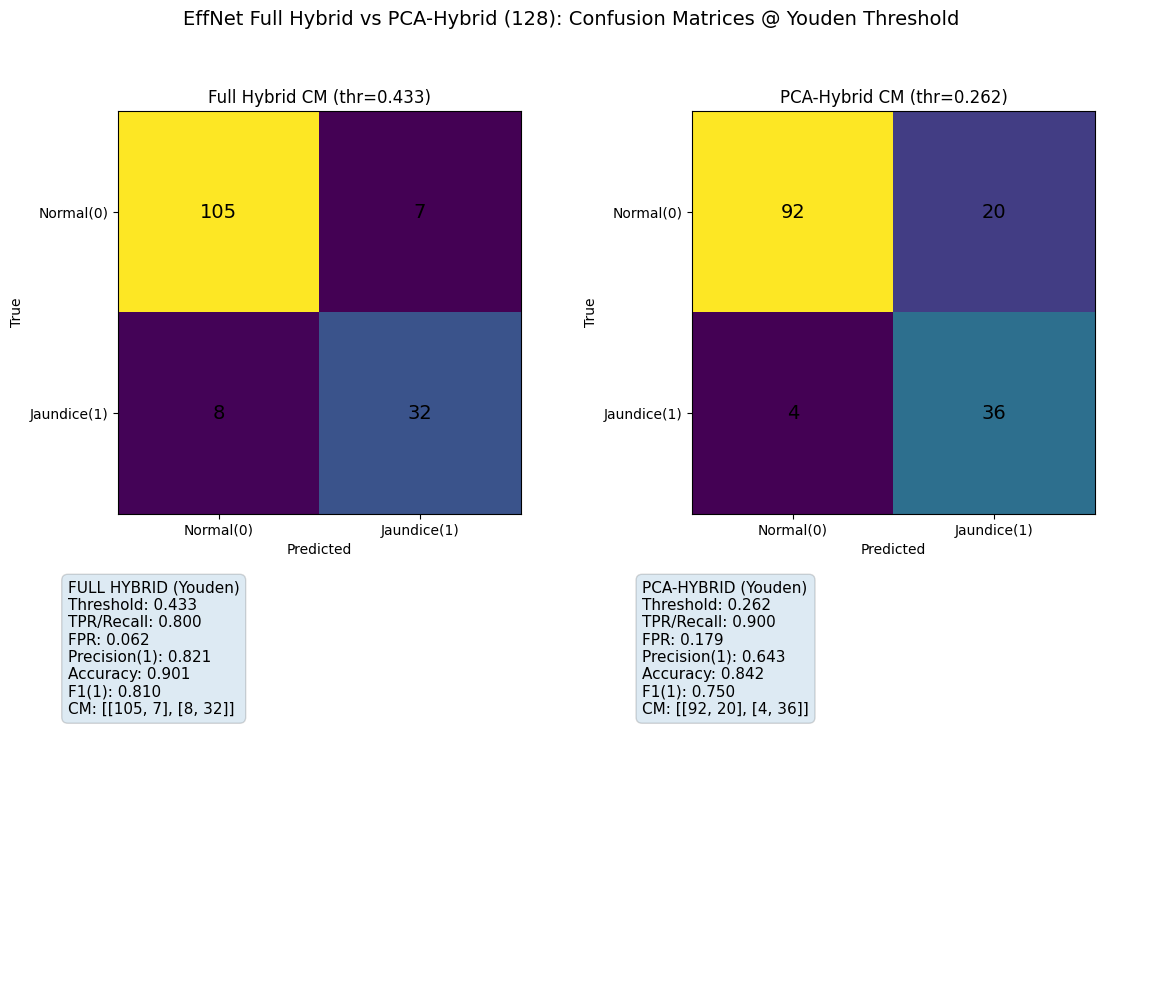

Saved: EffNet_Full_vs_PCAHybrid_CMPanel.png
Full Youden thr: 0.43345673636537774 | CM: [[105, 7], [8, 32]]
PCA  Youden thr: 0.26191797257180366 | CM: [[92, 20], [4, 36]]


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

y = y_test
p_full = prob_full
p_pca  = prob_pca

def youden_threshold(y_true, prob):
    fpr, tpr, thr = roc_curve(y_true, prob)
    j = tpr - fpr
    i = np.argmax(j)
    return thr[i], fpr[i], tpr[i]

def metrics_at_threshold(y_true, prob, thr):
    pred = (prob >= thr).astype(int)
    cm = confusion_matrix(y_true, pred)
    tn, fp, fn, tp = cm.ravel()
    acc = accuracy_score(y_true, pred)
    prec = precision_score(y_true, pred, zero_division=0)
    rec = recall_score(y_true, pred, zero_division=0)
    f1 = f1_score(y_true, pred, zero_division=0)
    fpr = fp/(fp+tn+1e-9)
    tpr = tp/(tp+fn+1e-9)
    return cm, acc, prec, rec, f1, fpr, tpr

# thresholds (Youden)
thrF, fprF, tprF = youden_threshold(y, p_full)
thrP, fprP, tprP = youden_threshold(y, p_pca)

# metrics
cmF, accF, precF, recF, f1F, FPRF, TPRF = metrics_at_threshold(y, p_full, thrF)
cmP, accP, precP, recP, f1P, FPRP, TPRP = metrics_at_threshold(y, p_pca, thrP)

# plot
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("EffNet Full Hybrid vs PCA-Hybrid (128): Confusion Matrices @ Youden Threshold", fontsize=14)

# --- Full CM ---
ax[0,0].imshow(cmF)
ax[0,0].set_title(f"Full Hybrid CM (thr={thrF:.3f})")
ax[0,0].set_xticks([0,1]); ax[0,0].set_yticks([0,1])
ax[0,0].set_xticklabels(["Normal(0)", "Jaundice(1)"])
ax[0,0].set_yticklabels(["Normal(0)", "Jaundice(1)"])
for i in range(2):
    for j in range(2):
        ax[0,0].text(j, i, cmF[i,j], ha="center", va="center", fontsize=14)
ax[0,0].set_xlabel("Predicted"); ax[0,0].set_ylabel("True")

# --- PCA CM ---
ax[0,1].imshow(cmP)
ax[0,1].set_title(f"PCA-Hybrid CM (thr={thrP:.3f})")
ax[0,1].set_xticks([0,1]); ax[0,1].set_yticks([0,1])
ax[0,1].set_xticklabels(["Normal(0)", "Jaundice(1)"])
ax[0,1].set_yticklabels(["Normal(0)", "Jaundice(1)"])
for i in range(2):
    for j in range(2):
        ax[0,1].text(j, i, cmP[i,j], ha="center", va="center", fontsize=14)
ax[0,1].set_xlabel("Predicted"); ax[0,1].set_ylabel("True")

# --- Full summary box ---
ax[1,0].axis("off")
txtF = (
    f"FULL HYBRID (Youden)\n"
    f"Threshold: {thrF:.3f}\n"
    f"TPR/Recall: {TPRF:.3f}\n"
    f"FPR: {FPRF:.3f}\n"
    f"Precision(1): {precF:.3f}\n"
    f"Accuracy: {accF:.3f}\n"
    f"F1(1): {f1F:.3f}\n"
    f"CM: {cmF.tolist()}"
)
ax[1,0].text(0.02, 0.98, txtF, va="top", fontsize=11,
             bbox=dict(boxstyle="round,pad=0.4", alpha=0.15))

# --- PCA summary box ---
ax[1,1].axis("off")
txtP = (
    f"PCA-HYBRID (Youden)\n"
    f"Threshold: {thrP:.3f}\n"
    f"TPR/Recall: {TPRP:.3f}\n"
    f"FPR: {FPRP:.3f}\n"
    f"Precision(1): {precP:.3f}\n"
    f"Accuracy: {accP:.3f}\n"
    f"F1(1): {f1P:.3f}\n"
    f"CM: {cmP.tolist()}"
)
ax[1,1].text(0.02, 0.98, txtP, va="top", fontsize=11,
             bbox=dict(boxstyle="round,pad=0.4", alpha=0.15))

plt.tight_layout(rect=[0, 0, 1, 0.95])

out_name = "EffNet_Full_vs_PCAHybrid_CMPanel.png"
plt.savefig(out_name, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_name)
print("Full Youden thr:", thrF, "| CM:", cmF.tolist())
print("PCA  Youden thr:", thrP, "| CM:", cmP.tolist())

In [19]:
from google.colab import files
files.download("EffNet_Full_vs_PCAHybrid_CMPanel.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**One-Cell Final Figure Pack Exporter (Save + Download)**

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from tqdm import tqdm
from google.colab import files

y = y_test
p_full = prob_full
p_pca  = prob_pca

# -----------------------------
# Helpers
# -----------------------------
def youden_point(y_true, prob):
    fpr, tpr, thr = roc_curve(y_true, prob)
    j = tpr - fpr
    i = np.argmax(j)
    return fpr, tpr, thr, i

def bootstrap_auc(y_true, y_prob, n_boot=2000, seed=42):
    rng = np.random.RandomState(seed)
    vals = []
    n = len(y_prob)
    for _ in tqdm(range(n_boot), desc="Bootstrap"):
        idx = rng.randint(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        vals.append(roc_auc_score(y_true[idx], y_prob[idx]))
    vals = np.array(vals)
    low, high = np.percentile(vals, 2.5), np.percentile(vals, 97.5)
    return vals, float(low), float(high), float(np.mean(vals))

def metrics_at_threshold(y_true, prob, thr):
    pred = (prob >= thr).astype(int)
    cm = confusion_matrix(y_true, pred)
    tn, fp, fn, tp = cm.ravel()
    acc = accuracy_score(y_true, pred)
    prec = precision_score(y_true, pred, zero_division=0)
    rec = recall_score(y_true, pred, zero_division=0)
    f1 = f1_score(y_true, pred, zero_division=0)
    fpr = fp/(fp+tn+1e-9)
    tpr = tp/(tp+fn+1e-9)
    return cm, acc, prec, rec, f1, fpr, tpr

# -----------------------------
# PANEL 1: ROC + PR + Calibration (3×2)
# -----------------------------
def make_panel_roc_pr_calib(y, p_full, p_pca, out_name):
    fprF, tprF, thrF, iF = youden_point(y, p_full)
    aucF = auc(fprF, tprF)
    precF, recF, _ = precision_recall_curve(y, p_full)
    apF = average_precision_score(y, p_full)
    brierF = brier_score_loss(y, p_full)
    fracF, meanF = calibration_curve(y, p_full, n_bins=10)

    fprP, tprP, thrP, iP = youden_point(y, p_pca)
    aucP = auc(fprP, tprP)
    precP, recP, _ = precision_recall_curve(y, p_pca)
    apP = average_precision_score(y, p_pca)
    brierP = brier_score_loss(y, p_pca)
    fracP, meanP = calibration_curve(y, p_pca, n_bins=10)

    fig, ax = plt.subplots(3, 2, figsize=(12, 14))
    fig.suptitle("EffNet Full Hybrid vs PCA-Hybrid (128): ROC + PR + Calibration", fontsize=14)

    # ROC
    ax[0,0].plot(fprF, tprF, linewidth=2)
    ax[0,0].plot([0,1],[0,1],'--', color='gray')
    ax[0,0].scatter([fprF[iF]], [tprF[iF]], s=70)
    ax[0,0].annotate(f"Youden thr={thrF[iF]:.3f}\nFPR={fprF[iF]:.3f}, TPR={tprF[iF]:.3f}",
                     (fprF[iF], tprF[iF]), textcoords="offset points", xytext=(10,-15),
                     bbox=dict(boxstyle="round,pad=0.25", alpha=0.15))
    ax[0,0].set_title(f"ROC — Full (AUC={aucF:.3f})"); ax[0,0].set_xlabel("FPR"); ax[0,0].set_ylabel("TPR"); ax[0,0].grid(alpha=0.25)

    ax[0,1].plot(fprP, tprP, linewidth=2)
    ax[0,1].plot([0,1],[0,1],'--', color='gray')
    ax[0,1].scatter([fprP[iP]], [tprP[iP]], s=70)
    ax[0,1].annotate(f"Youden thr={thrP[iP]:.3f}\nFPR={fprP[iP]:.3f}, TPR={tprP[iP]:.3f}",
                     (fprP[iP], tprP[iP]), textcoords="offset points", xytext=(10,-15),
                     bbox=dict(boxstyle="round,pad=0.25", alpha=0.15))
    ax[0,1].set_title(f"ROC — PCA (AUC={aucP:.3f})"); ax[0,1].set_xlabel("FPR"); ax[0,1].set_ylabel("TPR"); ax[0,1].grid(alpha=0.25)

    # PR
    ax[1,0].plot(recF, precF, linewidth=2)
    ax[1,0].set_title(f"PR — Full (AP={apF:.3f})"); ax[1,0].set_xlabel("Recall"); ax[1,0].set_ylabel("Precision"); ax[1,0].grid(alpha=0.25)

    ax[1,1].plot(recP, precP, linewidth=2)
    ax[1,1].set_title(f"PR — PCA (AP={apP:.3f})"); ax[1,1].set_xlabel("Recall"); ax[1,1].set_ylabel("Precision"); ax[1,1].grid(alpha=0.25)

    # Calibration
    ax[2,0].plot(meanF, fracF, "o-"); ax[2,0].plot([0,1],[0,1],"--")
    ax[2,0].set_title(f"Calibration — Full (Brier={brierF:.3f})"); ax[2,0].set_xlabel("Mean Prob"); ax[2,0].set_ylabel("Frac Pos"); ax[2,0].grid(alpha=0.25)

    ax[2,1].plot(meanP, fracP, "o-"); ax[2,1].plot([0,1],[0,1],"--")
    ax[2,1].set_title(f"Calibration — PCA (Brier={brierP:.3f})"); ax[2,1].set_xlabel("Mean Prob"); ax[2,1].set_ylabel("Frac Pos"); ax[2,1].grid(alpha=0.25)

    plt.tight_layout(rect=[0,0,1,0.97])
    plt.savefig(out_name, dpi=300, bbox_inches="tight")
    plt.close(fig)

# -----------------------------
# PANEL 2: Probability + Bootstrap AUC (2×2)
# -----------------------------
def make_panel_prob_boot(y, p_full, p_pca, out_name):
    boot_full, lowF, highF, meanF = bootstrap_auc(y, p_full, n_boot=2000, seed=42)
    boot_pca,  lowP, highP, meanP = bootstrap_auc(y, p_pca,  n_boot=2000, seed=43)

    auc_full = roc_auc_score(y, p_full)
    auc_pca  = roc_auc_score(y, p_pca)

    fig, ax = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle("EffNet Full Hybrid vs PCA-Hybrid: Probability + Bootstrap AUC", fontsize=14)

    ax[0,0].hist(p_full[y==0], bins=15, alpha=0.6, label="Normal(0)")
    ax[0,0].hist(p_full[y==1], bins=15, alpha=0.6, label="Jaundice(1)")
    ax[0,0].set_title(f"Full — Prob (AUC={auc_full:.3f})"); ax[0,0].legend(); ax[0,0].grid(alpha=0.2)

    ax[0,1].hist(p_pca[y==0], bins=15, alpha=0.6, label="Normal(0)")
    ax[0,1].hist(p_pca[y==1], bins=15, alpha=0.6, label="Jaundice(1)")
    ax[0,1].set_title(f"PCA — Prob (AUC={auc_pca:.3f})"); ax[0,1].legend(); ax[0,1].grid(alpha=0.2)

    ax[1,0].hist(boot_full, bins=30, alpha=0.75)
    ax[1,0].axvline(lowF, linestyle="--", label=f"2.5%={lowF:.3f}")
    ax[1,0].axvline(highF, linestyle="--", label=f"97.5%={highF:.3f}")
    ax[1,0].axvline(meanF, label=f"Mean={meanF:.3f}")
    ax[1,0].set_title("Full — Bootstrap AUC (95% CI)"); ax[1,0].legend(); ax[1,0].grid(alpha=0.2)

    ax[1,1].hist(boot_pca, bins=30, alpha=0.75)
    ax[1,1].axvline(lowP, linestyle="--", label=f"2.5%={lowP:.3f}")
    ax[1,1].axvline(highP, linestyle="--", label=f"97.5%={highP:.3f}")
    ax[1,1].axvline(meanP, label=f"Mean={meanP:.3f}")
    ax[1,1].set_title("PCA — Bootstrap AUC (95% CI)"); ax[1,1].legend(); ax[1,1].grid(alpha=0.2)

    plt.tight_layout(rect=[0,0,1,0.96])
    plt.savefig(out_name, dpi=300, bbox_inches="tight")
    plt.close(fig)

# -----------------------------
# PANEL 3: Confusion Matrices + Summary (2×2)
# -----------------------------
def make_panel_cm_summary(y, p_full, p_pca, out_name):
    fprF, tprF, thrF, iF = youden_point(y, p_full)
    fprP, tprP, thrP, iP = youden_point(y, p_pca)
    thr_full = thrF[iF]
    thr_pca  = thrP[iP]

    cmF, accF, precF, recF, f1F, FPRF, TPRF = metrics_at_threshold(y, p_full, thr_full)
    cmP, accP, precP, recP, f1P, FPRP, TPRP = metrics_at_threshold(y, p_pca,  thr_pca)

    fig, ax = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle("EffNet Full Hybrid vs PCA-Hybrid: Confusion Matrices @ Youden", fontsize=14)

    ax[0,0].imshow(cmF); ax[0,0].set_title(f"Full CM (thr={thr_full:.3f})")
    ax[0,0].set_xticks([0,1]); ax[0,0].set_yticks([0,1])
    ax[0,0].set_xticklabels(["Normal(0)","Jaundice(1)"])
    ax[0,0].set_yticklabels(["Normal(0)","Jaundice(1)"])
    for i in range(2):
        for j in range(2):
            ax[0,0].text(j, i, cmF[i,j], ha="center", va="center", fontsize=14)
    ax[0,0].set_xlabel("Pred"); ax[0,0].set_ylabel("True")

    ax[0,1].imshow(cmP); ax[0,1].set_title(f"PCA CM (thr={thr_pca:.3f})")
    ax[0,1].set_xticks([0,1]); ax[0,1].set_yticks([0,1])
    ax[0,1].set_xticklabels(["Normal(0)","Jaundice(1)"])
    ax[0,1].set_yticklabels(["Normal(0)","Jaundice(1)"])
    for i in range(2):
        for j in range(2):
            ax[0,1].text(j, i, cmP[i,j], ha="center", va="center", fontsize=14)
    ax[0,1].set_xlabel("Pred"); ax[0,1].set_ylabel("True")

    ax[1,0].axis("off")
    ax[1,0].text(0.02, 0.98,
                 f"FULL (Youden)\nthr={thr_full:.3f}\nTPR={TPRF:.3f}\nFPR={FPRF:.3f}\nPrec(1)={precF:.3f}\nAcc={accF:.3f}\nF1(1)={f1F:.3f}\nCM={cmF.tolist()}",
                 va="top", fontsize=11, bbox=dict(boxstyle="round,pad=0.4", alpha=0.15))

    ax[1,1].axis("off")
    ax[1,1].text(0.02, 0.98,
                 f"PCA (Youden)\nthr={thr_pca:.3f}\nTPR={TPRP:.3f}\nFPR={FPRP:.3f}\nPrec(1)={precP:.3f}\nAcc={accP:.3f}\nF1(1)={f1P:.3f}\nCM={cmP.tolist()}",
                 va="top", fontsize=11, bbox=dict(boxstyle="round,pad=0.4", alpha=0.15))

    plt.tight_layout(rect=[0,0,1,0.95])
    plt.savefig(out_name, dpi=300, bbox_inches="tight")
    plt.close(fig)

# -----------------------------
# RUN: generate all 3 panels
# -----------------------------
panel1 = "FIG_PANEL_1_ROC_PR_CALIB.png"
panel2 = "FIG_PANEL_2_PROB_BOOT.png"
panel3 = "FIG_PANEL_3_CM_SUMMARY.png"

make_panel_roc_pr_calib(y, p_full, p_pca, panel1)
make_panel_prob_boot(y, p_full, p_pca, panel2)
make_panel_cm_summary(y, p_full, p_pca, panel3)

print("Saved:", panel1)
print("Saved:", panel2)
print("Saved:", panel3)

# Download all
files.download(panel1)
files.download(panel2)
files.download(panel3)

Bootstrap: 100%|██████████| 2000/2000 [00:03<00:00, 648.25it/s]


Saved: FIG_PANEL_1_ROC_PR_CALIB.png
Saved: FIG_PANEL_2_PROB_BOOT.png
Saved: FIG_PANEL_3_CM_SUMMARY.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Save artifacts (deployment bundle)**

In [13]:
import joblib

meta = {
    "best_model": "EffNet Full Hybrid",
    "pca_dim": pca_dim,
    "note": "Same test split used for Full vs PCA hybrid evaluation",
}

joblib.dump(imputer, "eff_imputer.pkl")
joblib.dump(pca, "eff_pca_128.pkl")
joblib.dump(svm_full, "eff_svm_full.pkl")
joblib.dump(svm_pca,  "eff_svm_pca.pkl")
joblib.dump(meta, "eff_fullpack_meta.pkl")

print("Saved: eff_imputer.pkl, eff_pca_128.pkl, eff_svm_full.pkl, eff_svm_pca.pkl, eff_fullpack_meta.pkl")

Saved: eff_imputer.pkl, eff_pca_128.pkl, eff_svm_full.pkl, eff_svm_pca.pkl, eff_fullpack_meta.pkl
